In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
from scipy import stats
from collections import Counter
from statsmodels.stats.contingency_tables import StratifiedTable


In [2]:
!apt-get install -y fonts-nanum -q > /dev/null

import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [3]:
df = pd.read_csv("/content/FDA_adverse_events_final.csv")

In [4]:
m_group = df[df["WHO_ATC"] == "M"]

In [5]:
def is_naproxen_only(row):
    text = f"{row['suspect_drug']} {row['brand_name']}".upper()
    has_ibu = any(k in text for k in ["IBUPROFEN", "ADVIL", "MOTRIN", "BRUFEN", "NUROFEN"])
    has_nap = any(k in text for k in ["NAPROXEN", "ALEVE"])
    has_dic = any(k in text for k in ["DICLOFENAC", "VOLTAREN", "ASPERCREME"])
    return has_nap and not has_ibu and not has_dic

naproxen_group = m_group[m_group.apply(is_naproxen_only, axis=1)]

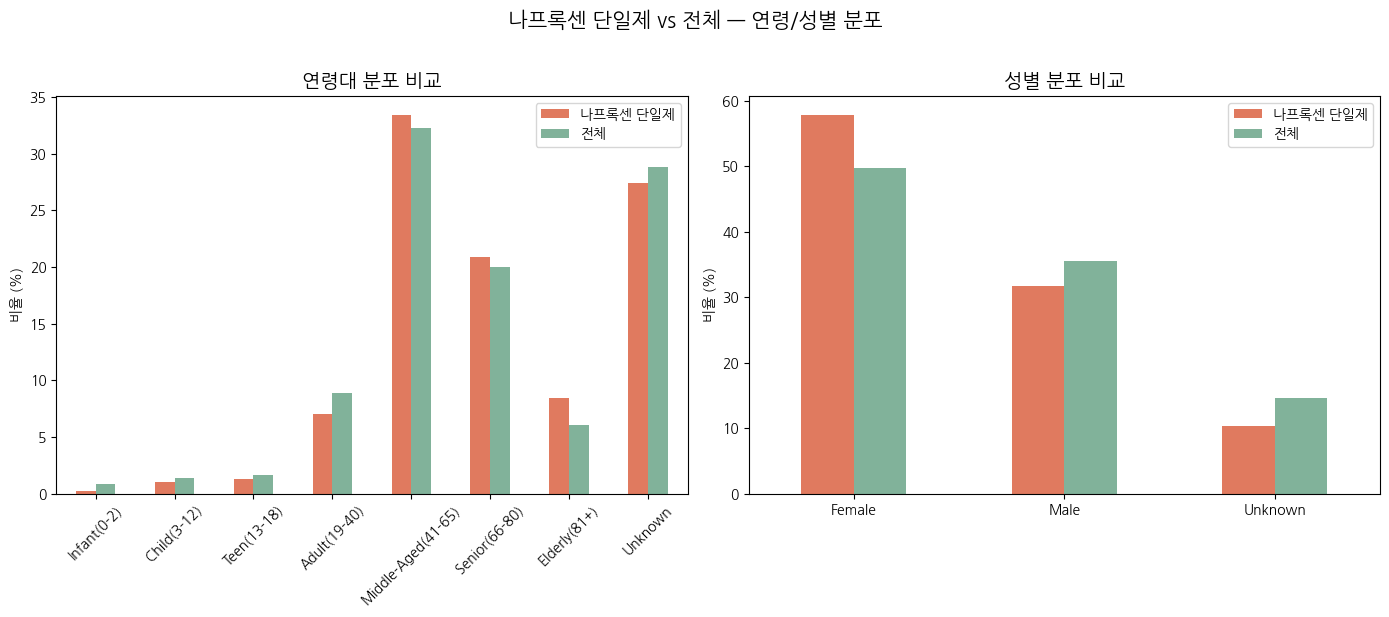

In [6]:
# 연령 / 성별 분포 비교 vs 전체 그래프
age_order = ["Infant(0-2)", "Child(3-12)", "Teen(13-18)", "Adult(19-40)",
             "Middle-Aged(41-65)", "Senior(66-80)", "Elderly(81+)", "Unknown"]
sex_order = ["Female", "Male", "Unknown"]

age_compare = pd.DataFrame({
    "나프록센 단일제": naproxen_group["age_group"].value_counts(normalize=True) * 100,
    "전체": df["age_group"].value_counts(normalize=True) * 100,
}).reindex(age_order).fillna(0)

sex_compare = pd.DataFrame({
    "나프록센 단일제": naproxen_group["patient_sex"].value_counts(normalize=True) * 100,
    "전체": df["patient_sex"].value_counts(normalize=True) * 100,
}).reindex(sex_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

age_compare.plot(kind="bar", ax=axes[0], color=["#e07a5f", "#81b29a"])
axes[0].set_title("연령대 분포 비교", fontsize=14)
axes[0].set_ylabel("비율 (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="")

sex_compare.plot(kind="bar", ax=axes[1], color=["#e07a5f", "#81b29a"])
axes[1].set_title("성별 분포 비교", fontsize=14)
axes[1].set_ylabel("비율 (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title="")

plt.suptitle("나프록센 단일제 vs 전체 — 연령/성별 분포", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

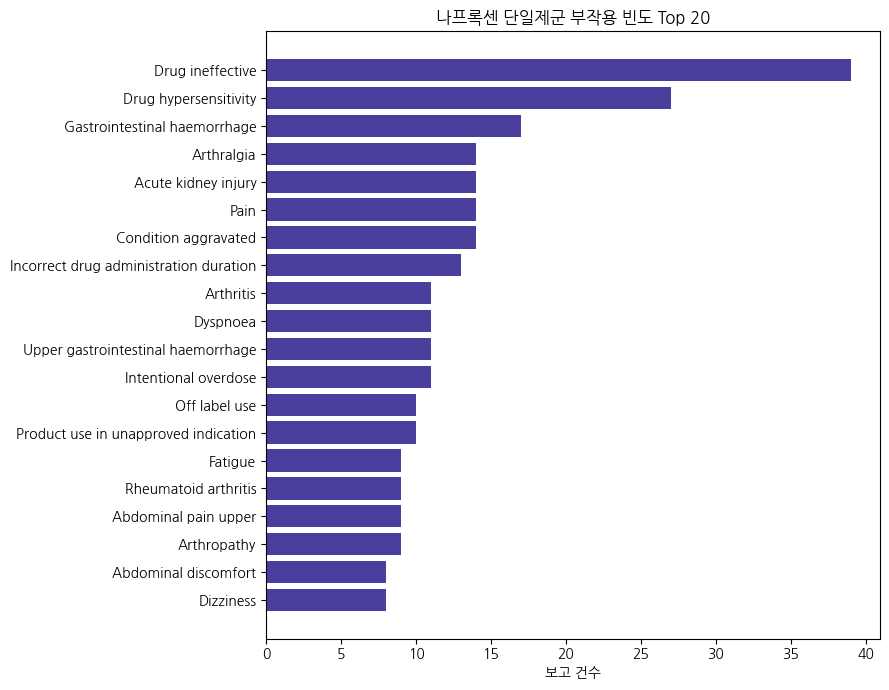

In [7]:
# 부작용 top20

def pt_counter(sub_df):
    c = Counter()
    for x in sub_df["reactions"].dropna():
        pts = set(s.strip() for s in x.split(";"))
        c.update(pts)
    return c

nap_pt_counter = pt_counter(naproxen_group)

pt_top20 = pd.Series(nap_pt_counter).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 7))
plt.barh(pt_top20.index[::-1], pt_top20.values[::-1], color="#4b3f9e")
plt.xlabel("보고 건수")
plt.title(f"나프록센 단일제군 부작용 빈도 Top 20")
plt.tight_layout()
plt.show()

In [8]:
# PRR/ROR 계산

rest = df.drop(naproxen_group.index)

rest_pt_counter = pt_counter(rest)

N1 = len(naproxen_group)   # 나프록센군 전체 보고 수
N2 = len(rest)             # 나머지 전체 보고 수

all_pts = set(nap_pt_counter) | set(rest_pt_counter)

rows = []
for pt in all_pts:
    a = nap_pt_counter.get(pt, 0)
    if a < 3:          # 나프록센군 내 최소 3건 이상인 PT만 분석
        continue
    c = rest_pt_counter.get(pt, 0)
    b = N1 - a
    d = N2 - c

    # PRR
    prr = (a / (a + b)) / (c / (c + d)) if c > 0 else np.inf

    # ROR (0셀 보정)
    a2, b2, c2, d2 = a, b, c, d
    if min(a, b, c, d) == 0:
        a2, b2, c2, d2 = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    ror = (a2 * d2) / (b2 * c2)
    se = np.sqrt(1/a2 + 1/b2 + 1/c2 + 1/d2)
    ci_low = np.exp(np.log(ror) - 1.96 * se)
    ci_high = np.exp(np.log(ror) + 1.96 * se)

    # chi-square p-value
    chi2, p, _, _ = stats.chi2_contingency([[a, b], [c, d]], correction=False)

    rows.append(dict(PT=pt, a=a, b=b, c=c, d=d,
                      PRR=prr, ROR=ror, CI_low=ci_low, CI_high=ci_high,
                      chi2=chi2, p_value=p))

signal_df = pd.DataFrame(rows).sort_values("ROR", ascending=False).reset_index(drop=True)
print(f"분석 대상 PT 수 (나프록센군 내 3건 이상): {len(signal_df)}개")
signal_df.head(15).round(3)

분석 대상 PT 수 (나프록센군 내 3건 이상): 112개


,PT,a,b,c,d,PRR,ROR,CI_low,CI_high,chi2,p_value
0,Serum sickness-like reaction,3,365,0,17905,inf,342.923,17.680,6651.234,145.989,0.0
1,Gastrointestinal fistula,3,365,0,17905,inf,342.923,17.680,6651.234,145.989,0.0
2,Eosinophilic pneumonia,4,364,1,17904,194.620,196.747,21.936,1764.676,154.142,0.0
3,Bone density decreased,4,364,2,17903,97.310,98.368,17.960,538.774,127.135,0.0
4,Cutaneous vasculitis,4,364,4,17901,48.655,49.179,12.252,197.407,93.392,0.0
5,Femur fracture,3,365,5,17900,29.193,29.425,7.006,123.589,51.073,0.0
6,Adrenal insufficiency,7,361,14,17891,24.327,24.780,9.942,61.762,104.507,0.0
7,Bone disorder,3,365,7,17898,20.852,21.015,5.413,81.593,39.712,0.0
8,Drug effective for unapproved indication,5,363,12,17893,20.273,20.538,7.198,58.601,64.727,0.0
9,Duodenal ulcer,6,362,15,17890,19.462,19.768,7.626,51.241,75.144,0.0


In [9]:
signal_df["signal"] = (signal_df["PRR"] >= 2) & (signal_df["chi2"] >= 4) & (signal_df["a"] >= 3)
significant_pts = signal_df[signal_df["signal"]].sort_values("ROR", ascending=False).reset_index(drop=True)
significant_pts[["PT", "a", "c", "PRR", "ROR", "CI_low", "CI_high", "p_value"]].round(3)

,PT,a,c,PRR,ROR,CI_low,CI_high,p_value
0,Serum sickness-like reaction,3,0,inf,342.923,17.680,6651.234,0.000
1,Gastrointestinal fistula,3,0,inf,342.923,17.680,6651.234,0.000
2,Eosinophilic pneumonia,4,1,194.620,196.747,21.936,1764.676,0.000
3,Bone density decreased,4,2,97.310,98.368,17.960,538.774,0.000
4,Cutaneous vasculitis,4,4,48.655,49.179,12.252,197.407,0.000
...,...,...,...,...,...,...,...,...
66,Fall,7,139,2.450,2.478,1.152,5.333,0.016
67,Fatigue,9,188,2.329,2.363,1.201,4.649,0.010
68,Suicide attempt,7,149,2.286,2.311,1.075,4.966,0.027
69,Anaemia,7,155,2.197,2.221,1.034,4.769,0.036


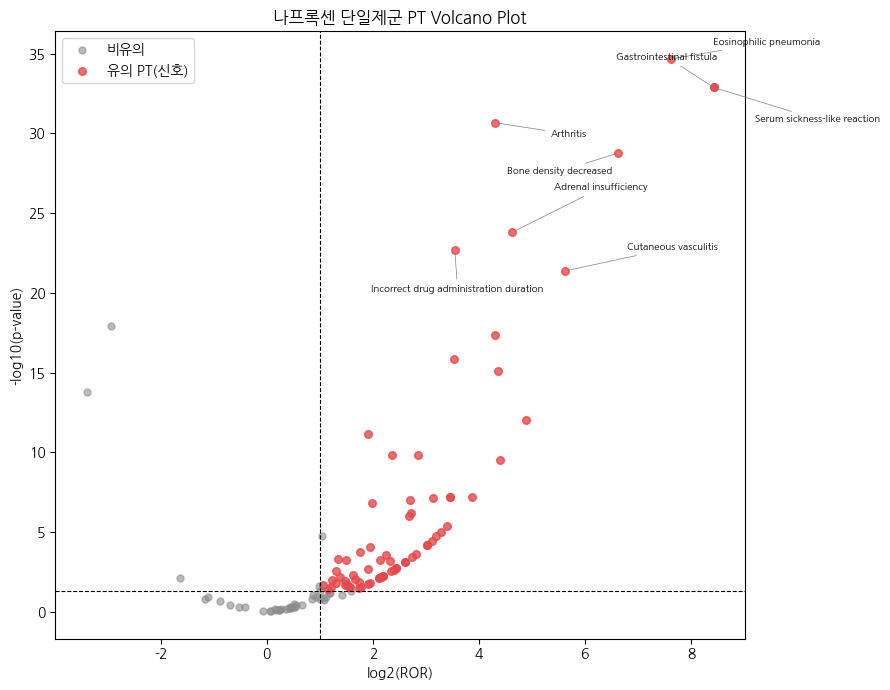

In [10]:
plot_df = signal_df.copy()
plot_df["log2_ROR"] = np.log2(plot_df["ROR"])
plot_df["neg_log10_p"] = -np.log10(plot_df["p_value"].clip(lower=1e-300))

fig, ax = plt.subplots(figsize=(9, 7))
non_sig = plot_df[~plot_df["signal"]]
sig = plot_df[plot_df["signal"]]

ax.scatter(non_sig["log2_ROR"], non_sig["neg_log10_p"], color="#8c8c8c", alpha=0.6, s=25, label="비유의")
ax.scatter(sig["log2_ROR"], sig["neg_log10_p"], color="#e6484a", alpha=0.8, s=30, label="유의 PT(신호)")

ax.axvline(np.log2(2), color="black", linestyle="--", linewidth=0.8)
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)

# 상위 신호 라벨 표시 (겹침 방지를 위해 점마다 오프셋을 다르게 줌)
top_label = sig.sort_values("neg_log10_p", ascending=False).head(8).reset_index(drop=True)
offsets = [(30, 10), (30, -25), (-70, 20), (40, -10), (-80, -15), (30, 30), (-60, -30), (45, 15)]
for i, row in enumerate(top_label.itertuples()):
    ox, oy = offsets[i % len(offsets)]
    ax.annotate(row.PT, (row.log2_ROR, row.neg_log10_p), fontsize=7,
                xytext=(ox, oy), textcoords="offset points",
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

ax.set_xlabel("log2(ROR)")
ax.set_ylabel("-log10(p-value)")
ax.set_title("나프록센 단일제군 PT Volcano Plot")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
misuse_pts = [
    "Incorrect drug administration duration", "Extra dose administered",
    "Wrong technique in product usage process", "Contraindicated product administered",
    "Off label use", "Product use in unapproved indication", "Intentional overdose",
    "Drug effective for unapproved indication", "Expired product administered",
    "Incorrect product administration duration", "Medication error",
]
ineffective_pts = [
    "Drug ineffective", "Therapeutic response unexpected",
    "Therapeutic product effect decreased", "Therapeutic product effect incomplete",
    "Drug effect decreased",
]
exclude_pts = set(misuse_pts) | set(ineffective_pts)

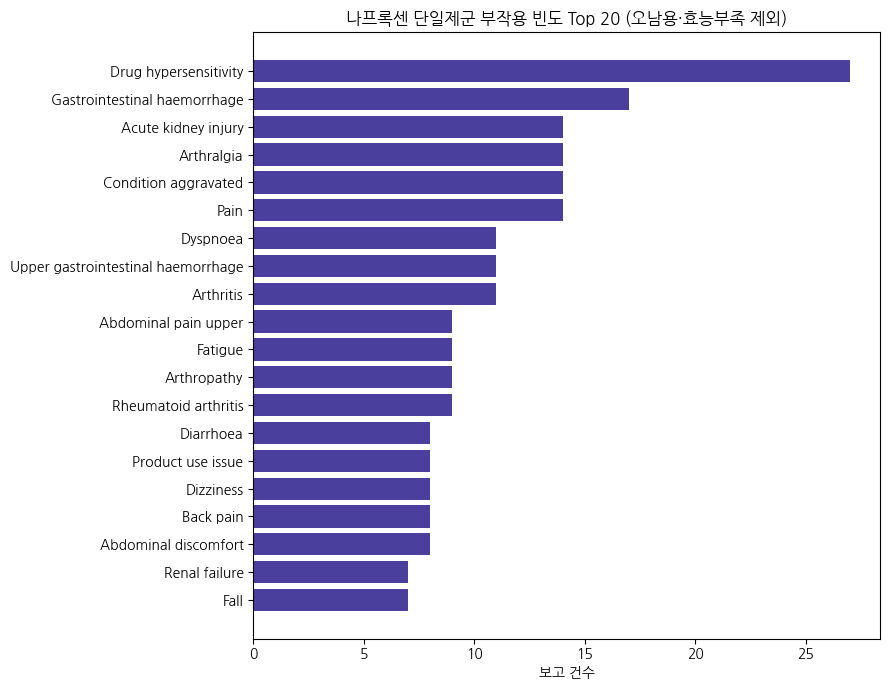

In [12]:
nap_pt_counter_adr = Counter({k: v for k, v in nap_pt_counter.items() if k not in exclude_pts})
pt_top20_adr = pd.Series(nap_pt_counter_adr).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 7))
plt.barh(pt_top20_adr.index[::-1], pt_top20_adr.values[::-1], color="#4b3f9e")
plt.xlabel("보고 건수")
plt.title(f"나프록센 단일제군 부작용 빈도 Top 20 (오남용·효능부족 제외)")
plt.tight_layout()
plt.show()

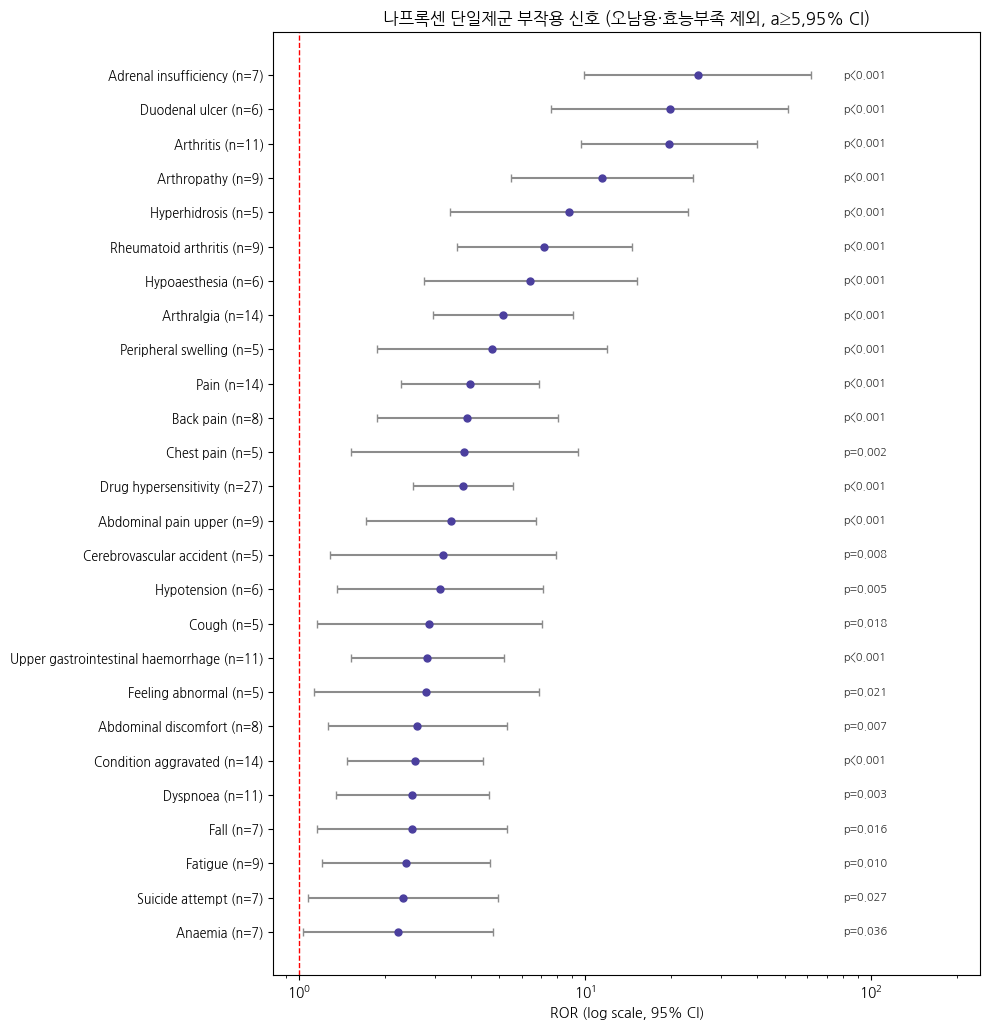

In [13]:
adr_only = significant_pts[~significant_pts["PT"].isin(exclude_pts)].reset_index(drop=True)
forest_data = adr_only[adr_only["a"] >= 5].sort_values("ROR").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(forest_data) * 0.4)))
y_pos = np.arange(len(forest_data))
err_low = forest_data["ROR"] - forest_data["CI_low"]
err_high = forest_data["CI_high"] - forest_data["ROR"]
ax.errorbar(forest_data["ROR"], y_pos, xerr=[err_low, err_high],
            fmt="o", color="#4b3f9e", ecolor="#8c8c8c", capsize=3, markersize=5)
ax.axvline(1, color="red", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row.PT} (n={row.a})" for row in forest_data.itertuples()], fontsize=9)
ax.set_xlabel("ROR (log scale, 95% CI)")
ax.set_title(f"나프록센 단일제군 부작용 신호 (오남용·효능부족 제외, a≥5,95% CI)")

x_text = forest_data["CI_high"].max() * 1.3
for i, row in enumerate(forest_data.itertuples()):
    p_str = "p<0.001" if row.p_value < 0.001 else f"p={row.p_value:.3f}"
    ax.text(x_text, i, p_str, va="center", fontsize=8, color="#333333")
ax.set_xlim(right=x_text * 3)
plt.tight_layout()
plt.show()

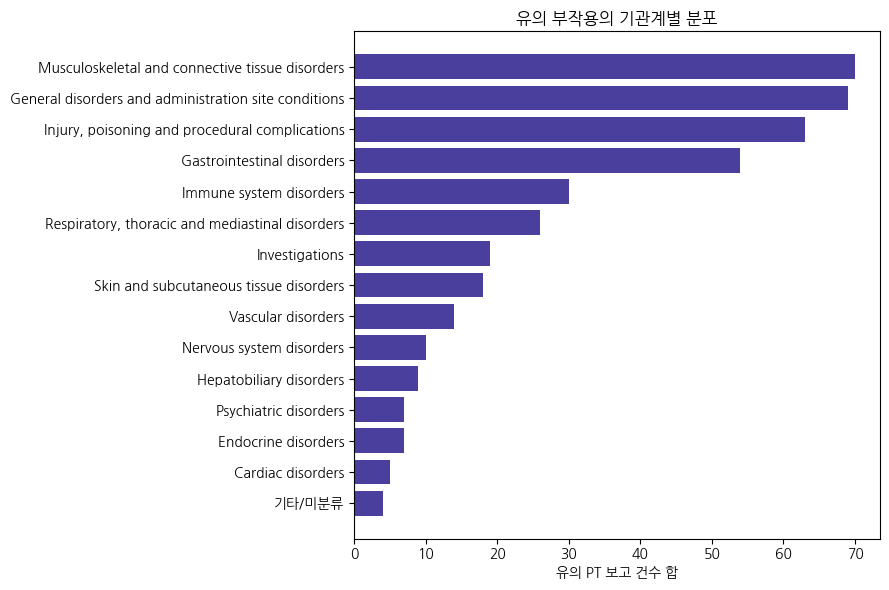

In [14]:
soc_map = {
    "Gastrointestinal disorders": ["Gastrointestinal haemorrhage", "Upper gastrointestinal haemorrhage",
        "Duodenal ulcer", "Gastric haemorrhage", "Duodenal ulcer perforation", "Abdominal pain upper",
        "Abdominal discomfort", "Colitis", "Gastrointestinal fistula", "Diarrhoea", "Gastric ulcer haemorrhage",
        "Haematemesis"],
    "Musculoskeletal and connective tissue disorders": ["Arthralgia", "Arthritis", "Arthropathy",
        "Rheumatoid arthritis", "Back pain", "Bone density decreased", "Bone disorder", "Femur fracture",
        "Musculoskeletal pain", "Musculoskeletal stiffness", "Muscle spasms"],
    "Immune system disorders": ["Drug hypersensitivity", "Serum sickness-like reaction", "Anaphylactic reaction"],
    "Skin and subcutaneous tissue disorders": ["Cutaneous vasculitis", "Hyperhidrosis", "Petechiae", "Psoriasis",
        "Blister"],
    "Renal and urinary disorders": ["Acute kidney injury", "Renal failure", "Renal impairment"],
    "Endocrine disorders": ["Adrenal insufficiency"],
    "Respiratory, thoracic and mediastinal disorders": ["Dyspnoea", "Interstitial lung disease", "Cough",
        "Lower respiratory tract infection", "Oropharyngeal pain"],
    "Cardiac disorders": ["Cardiac arrest", "Chest pain"],
    "Vascular disorders": ["Cerebrovascular accident", "Hypotension", "Shock haemorrhagic"],
    "Nervous system disorders": ["Dizziness", "Hypoaesthesia", "Syncope"],
    "Hepatobiliary disorders": ["Liver disorder", "Blood bilirubin increased", "Hepatic enzyme increased"],
    "General disorders and administration site conditions": ["Pain", "Fatigue", "Condition aggravated",
        "Feeling abnormal", "Peripheral swelling", "Therapeutic response unexpected", "Drug effect decreased",
        "Therapeutic product effect decreased", "Therapeutic product effect incomplete", "Swelling",
        "Adverse event"],
    "Injury, poisoning and procedural complications": ["Incorrect drug administration duration",
        "Extra dose administered", "Wrong technique in product usage process", "Contraindicated product administered",
        "Fall", "Off label use", "Product use in unapproved indication", "Intentional overdose",
        "Drug effective for unapproved indication", "Expired product administered",
        "Incorrect product administration duration", "Medication error"],
    "Investigations": ["C-reactive protein abnormal", "Leukocytosis", "Anaemia",
        "International normalised ratio increased", "Haemoglobin decreased"],
    "Psychiatric disorders": ["Suicide attempt"],
}

pt_to_soc = {pt: soc for soc, pts in soc_map.items() for pt in pts}

significant_pts["SOC"] = significant_pts["PT"].map(pt_to_soc).fillna("기타/미분류")

soc_counts = significant_pts.groupby("SOC")["a"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(soc_counts.index[::-1], soc_counts.values[::-1], color="#4b3f9e")
ax.set_xlabel("유의 PT 보고 건수 합")
ax.set_title("유의 부작용의 기관계별 분포")
plt.tight_layout()
plt.show()

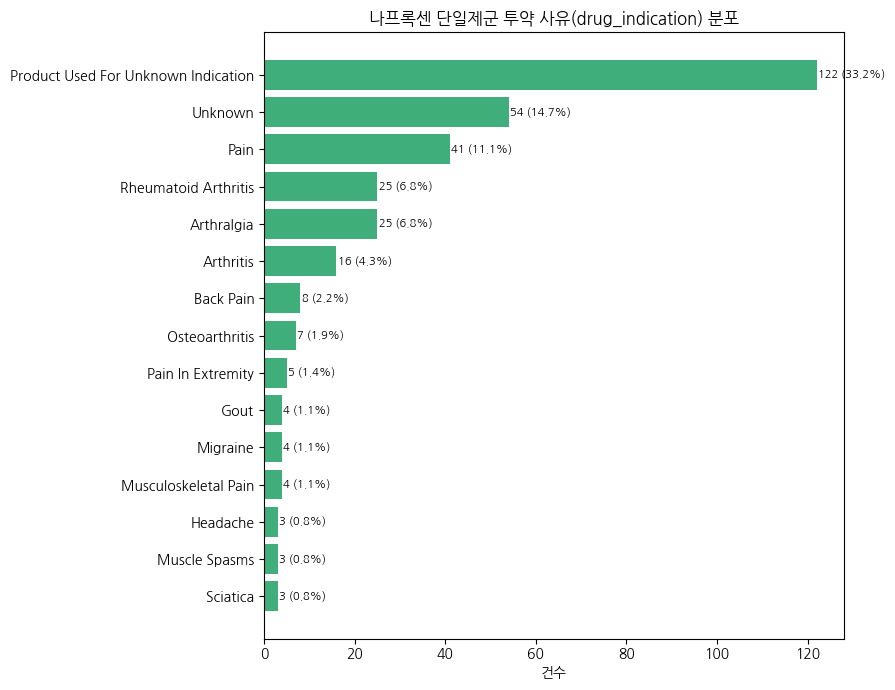

In [15]:
n = len(naproxen_group)
ind_top15 = naproxen_group["drug_indication"].value_counts().head(15)

plt.figure(figsize=(9, 7))
plt.barh(ind_top15.index[::-1], ind_top15.values[::-1], color="#3fae7a")
for i, v in enumerate(ind_top15.values[::-1]):
    plt.text(v + 0.3, i, f"{v} ({v/n*100:.1f}%)", va="center", fontsize=8)
plt.xlabel("건수")
plt.title(f"나프록센 단일제군 투약 사유(drug_indication) 분포")
plt.tight_layout()
plt.show()

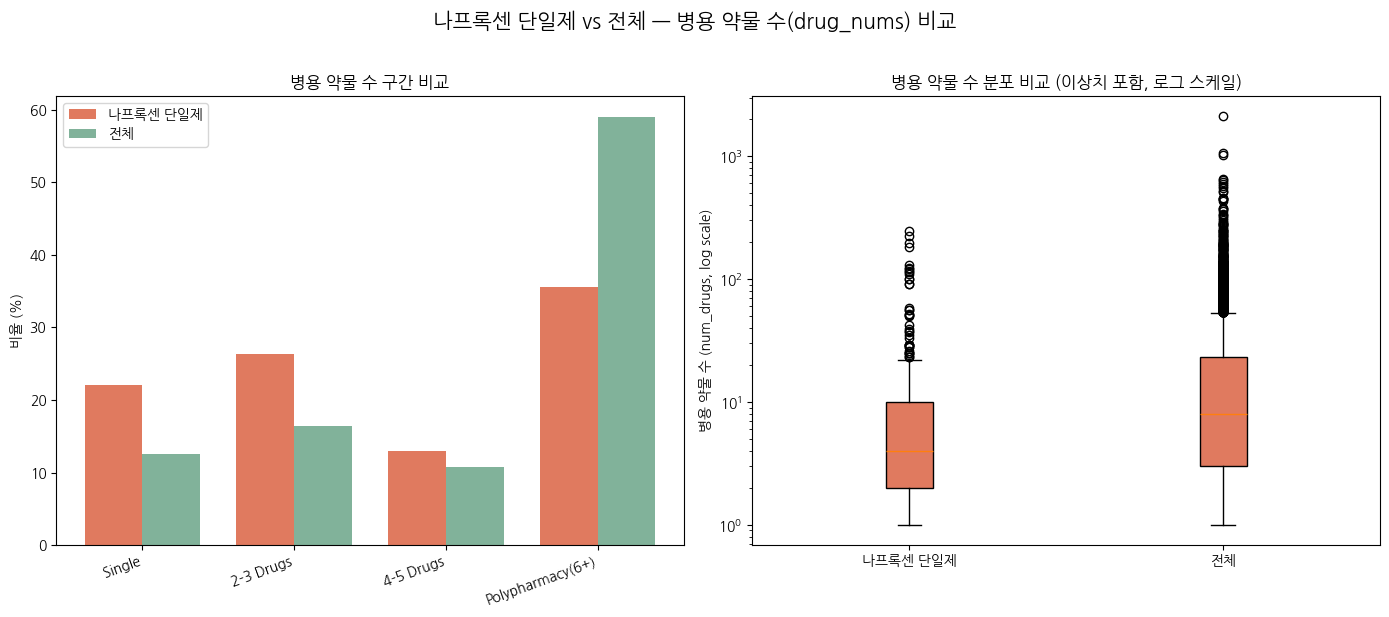

나프록센군 중앙값 4 (평균 12.44)
전체 중앙값 8 (평균 17.80)
Mann-Whitney U=2452054, p=4.549e-19


In [16]:
cat_order = ["Single", "2-3 Drugs", "4-5 Drugs", "Polypharmacy(6+)"]
nap_cat = naproxen_group["drug_count_category"].value_counts(normalize=True).reindex(cat_order).fillna(0) * 100
all_cat = df["drug_count_category"].value_counts(normalize=True).reindex(cat_order).fillna(0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(cat_order)); w = 0.38
axes[0].bar(x - w/2, nap_cat.values, w, color="#e07a5f", label="나프록센 단일제")
axes[0].bar(x + w/2, all_cat.values, w, color="#81b29a", label="전체")
axes[0].set_xticks(x); axes[0].set_xticklabels(cat_order, rotation=20, ha="right")
axes[0].set_ylabel("비율 (%)")
axes[0].set_title("병용 약물 수 구간 비교")
axes[0].legend()

axes[1].boxplot([naproxen_group["num_drugs"], df["num_drugs"]], tick_labels=["나프록센 단일제", "전체"],
                patch_artist=True, showfliers=True,
                boxprops=dict(facecolor="#e07a5f"))
axes[1].set_yscale("log")
axes[1].set_ylabel("병용 약물 수 (num_drugs, log scale)")
axes[1].set_title("병용 약물 수 분포 비교 (이상치 포함, 로그 스케일)")

plt.suptitle("나프록센 단일제 vs 전체 — 병용 약물 수(drug_nums) 비교", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

u_stat, p_u = stats.mannwhitneyu(naproxen_group["num_drugs"], df["num_drugs"], alternative="two-sided")
print(f"나프록센군 중앙값 {naproxen_group['num_drugs'].median():.0f} (평균 {naproxen_group['num_drugs'].mean():.2f})")
print(f"전체 중앙값 {df['num_drugs'].median():.0f} (평균 {df['num_drugs'].mean():.2f})")
print(f"Mann-Whitney U={u_stat:.0f}, p={p_u:.4g}")

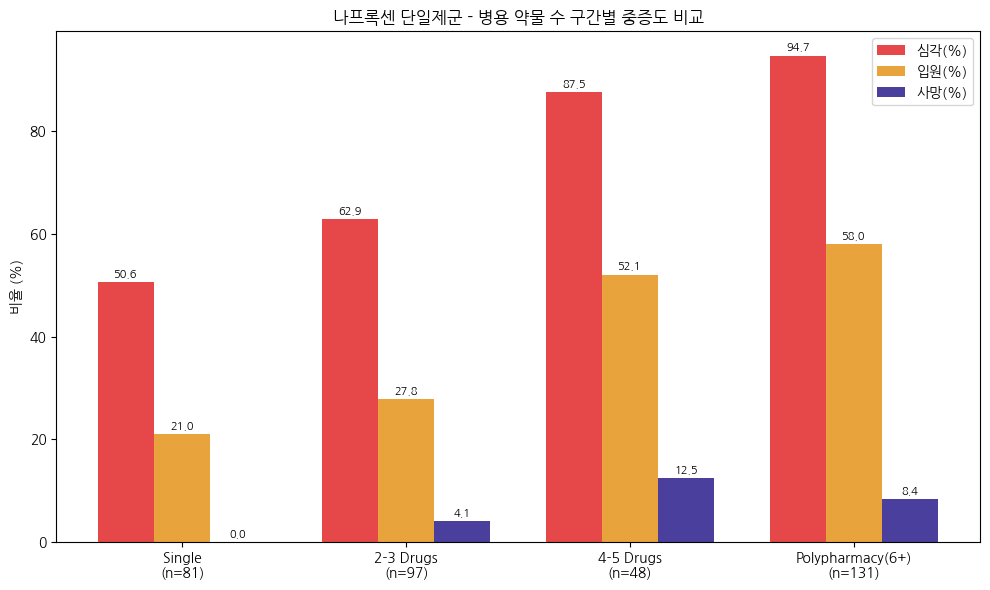

[구간 x serious] chi2=69.34, p=3.133e-14
[구간 순서 x serious] Spearman rho=0.417, p=1.922e-16


In [17]:
cat_order = ["Single", "2-3 Drugs", "4-5 Drugs", "Polypharmacy(6+)"]

tab = naproxen_group.groupby("drug_count_category").agg(
    n=("drug_count_category", "size"),
    serious=("serious", lambda s: (s == "Yes").mean() * 100),
    hosp=("is_hospitalized", lambda s: s.mean() * 100),
    fatal=("is_fatal", lambda s: s.mean() * 100),
).reindex(cat_order)

x = np.arange(len(cat_order)); w = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - w, tab["serious"], w, label="심각(%)", color="#e6484a")
ax.bar(x, tab["hosp"], w, label="입원(%)", color="#e8a33d")
ax.bar(x + w, tab["fatal"], w, label="사망(%)", color="#4b3f9e")
for i, cat in enumerate(cat_order):
    ax.text(i - w, tab.loc[cat, "serious"] + 1, f"{tab.loc[cat,'serious']:.1f}", ha="center", fontsize=8)
    ax.text(i, tab.loc[cat, "hosp"] + 1, f"{tab.loc[cat,'hosp']:.1f}", ha="center", fontsize=8)
    ax.text(i + w, tab.loc[cat, "fatal"] + 1, f"{tab.loc[cat,'fatal']:.1f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f"{c}\n(n={int(tab.loc[c,'n'])})" for c in cat_order])
ax.set_ylabel("비율 (%)")
ax.set_title("나프록센 단일제군 - 병용 약물 수 구간별 중증도 비교")
ax.legend()
plt.tight_layout()
plt.show()

ct = pd.crosstab(naproxen_group["drug_count_category"], naproxen_group["serious"])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"[구간 x serious] chi2={chi2:.2f}, p={p:.4g}")

order_map = {"Single":1, "2-3 Drugs":2, "4-5 Drugs":3, "Polypharmacy(6+)":4}
sub = naproxen_group[naproxen_group["drug_count_category"].isin(cat_order)].copy()  # ← Unknown 11건 제외
sub["cat_num"] = sub["drug_count_category"].map(order_map)
sub["serious_num"] = (sub["serious"]=="Yes").astype(int)
rho, p_rho = stats.spearmanr(sub["cat_num"], sub["serious_num"])
print(f"[구간 순서 x serious] Spearman rho={rho:.3f}, p={p_rho:.4g}")

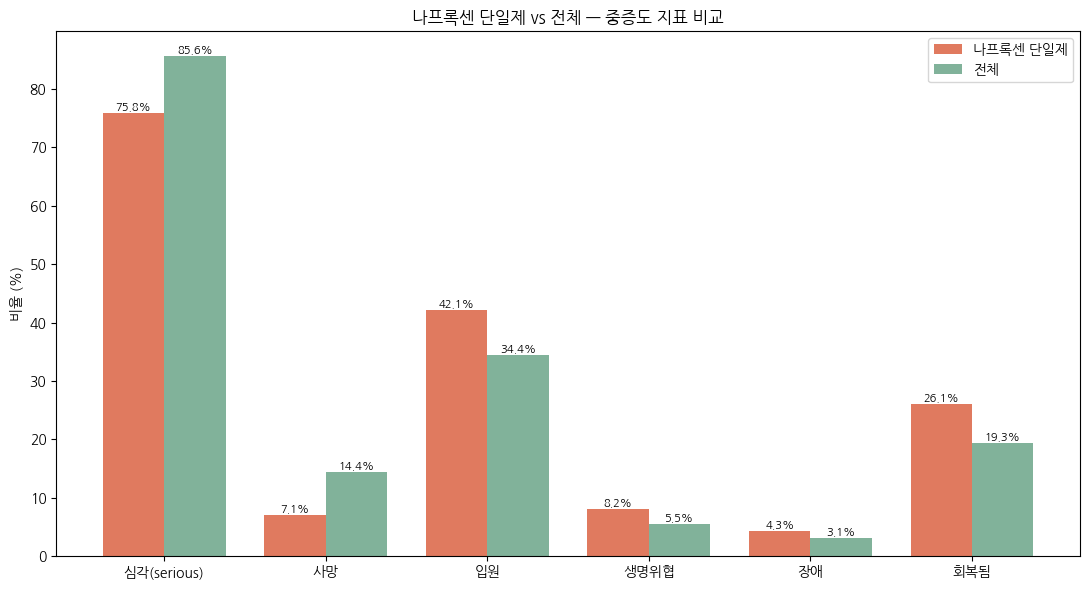

Chi-square 검정 (나프록센 vs 전체):
- 심각(serious): chi2=28.1, p=1.157e-07
- 사망: chi2=15.9, p=6.684e-05
- 입원: chi2=9.6, p=0.001901
- 생명위협: chi2=4.4, p=0.03576
- 장애: chi2=1.4, p=0.2342
- 회복됨: chi2=10.6, p=0.001155


In [18]:
labels = ["심각(serious)", "사망", "입원", "생명위협", "장애", "회복됨"]
cols = ["serious", "is_fatal", "is_hospitalized", "is_life_threat", "is_disabling", "patient_recovered"]

nap_rates = [(naproxen_group["serious"]=="Yes").mean()*100] + [naproxen_group[c].mean()*100 for c in cols[1:]]
all_rates = [(df["serious"]=="Yes").mean()*100] + [df[c].mean()*100 for c in cols[1:]]

x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w/2, nap_rates, w, color="#e07a5f", label="나프록센 단일제")
ax.bar(x + w/2, all_rates, w, color="#81b29a", label="전체")
for i,(a,b) in enumerate(zip(nap_rates, all_rates)):
    ax.text(i-w/2, a+0.5, f"{a:.1f}%", ha="center", fontsize=8)
    ax.text(i+w/2, b+0.5, f"{b:.1f}%", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("비율 (%)")
ax.set_title("나프록센 단일제 vs 전체 — 중증도 지표 비교")
ax.legend()
plt.tight_layout()
plt.show()

print("Chi-square 검정 (나프록센 vs 전체):")
for label, col in zip(labels, cols):
    if col == "serious":
        ct = pd.crosstab(df.index.isin(naproxen_group.index), df["serious"])
    else:
        ct = pd.crosstab(df.index.isin(naproxen_group.index), df[col])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    print(f"- {label}: chi2={chi2:.1f}, p={p:.4g}")

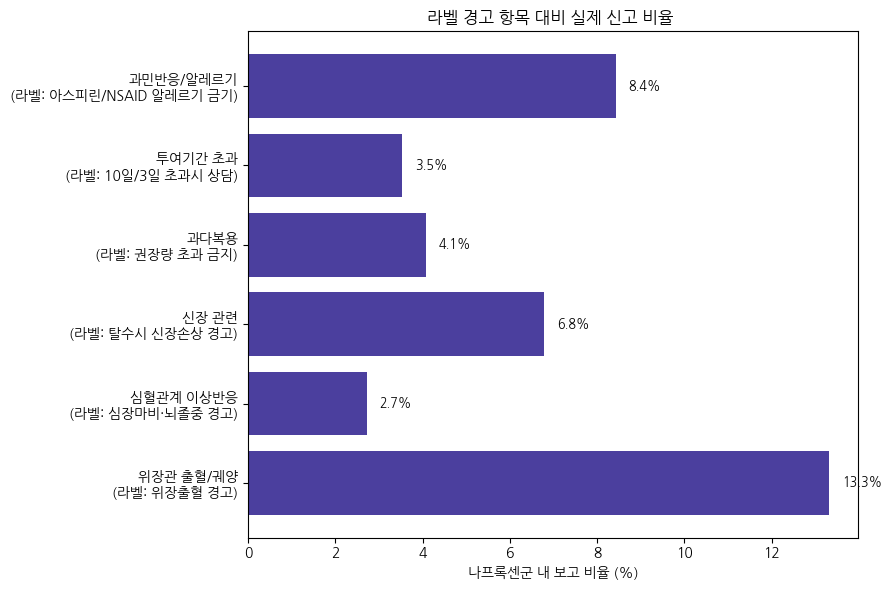

In [19]:
def contains_any(text, kws):
    if pd.isna(text): return False
    t = str(text).upper()
    return any(k.upper() in t for k in kws)

label_rows = [
    ("위장관 출혈/궤양\n(라벨: 위장출혈 경고)",
     ["Gastrointestinal haemorrhage","Upper gastrointestinal haemorrhage","Melaena","Haematemesis",
      "Peptic ulcer","Gastric ulcer","Duodenal ulcer"]),
    ("심혈관계 이상반응\n(라벨: 심장마비·뇌졸중 경고)",
     ["Myocardial infarction","Cardiac failure","Cerebrovascular accident","Cerebral infarction","Angina"]),
    ("신장 관련\n(라벨: 탈수시 신장손상 경고)",
     ["Renal failure","Renal impairment","Acute kidney injury"]),
    ("과다복용\n(라벨: 권장량 초과 금지)", ["Overdose","Intentional overdose"]),
    ("투여기간 초과\n(라벨: 10일/3일 초과시 상담)", ["Incorrect drug administration duration"]),
    ("과민반응/알레르기\n(라벨: 아스피린/NSAID 알레르기 금기)",
     ["Drug hypersensitivity","Anaphylactic","Urticaria"]),
]
label_pcts = [naproxen_group["reactions"].apply(lambda x: contains_any(x, kws)).mean()*100 for _, kws in label_rows]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([n for n,_ in label_rows], label_pcts, color="#4b3f9e")
for i, v in enumerate(label_pcts):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlabel("나프록센군 내 보고 비율 (%)")
ax.set_title(f"라벨 경고 항목 대비 실제 신고 비율 ")
plt.tight_layout()
plt.show()

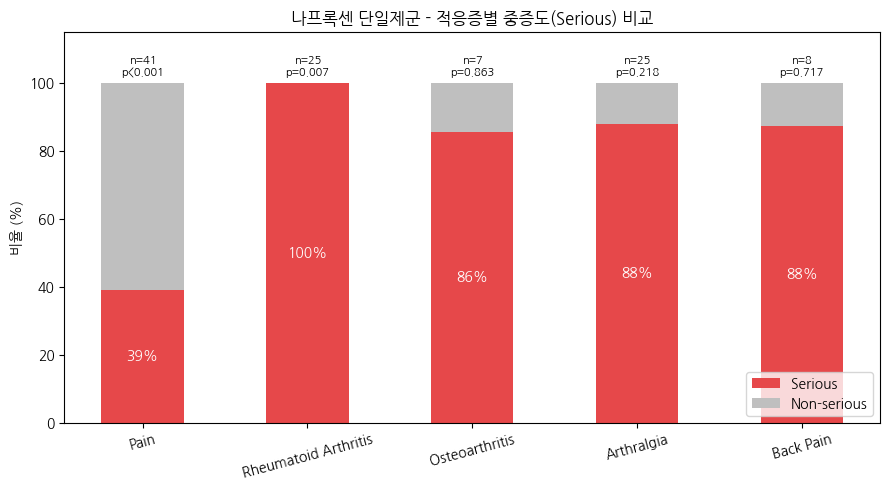

In [20]:
# ① 주요 신호 요약표
adr_only = significant_pts[~significant_pts["PT"].isin(exclude_pts)].copy()
summary_tbl = adr_only[adr_only["a"] >= 5].sort_values("ROR", ascending=False).reset_index(drop=True)
summary_tbl["SOC"] = summary_tbl["PT"].map(pt_to_soc).fillna("기타/미분류")
summary_tbl["ROR (95% CI)"] = summary_tbl.apply(
    lambda r: f"{r['ROR']:.2f} ({r['CI_low']:.2f}-{r['CI_high']:.2f})", axis=1)
summary_tbl["p-value"] = summary_tbl["p_value"].apply(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}")
summary_tbl["PRR"] = summary_tbl["PRR"].round(2)
final_tbl = summary_tbl[["PT", "a", "PRR", "ROR (95% CI)", "p-value", "SOC"]].rename(columns={"a": "사례수(n)"})
final_tbl

# ② 적응증별 중증도 비교
top_indications = ["Pain", "Rheumatoid Arthritis", "Osteoarthritis", "Arthralgia", "Back Pain"]
ind_rows = []
for ind in top_indications:
    sub = naproxen_group[naproxen_group["drug_indication"] == ind]
    n = len(sub)
    serious_pct = (sub["serious"]=="Yes").mean()*100
    ct = pd.crosstab(naproxen_group["drug_indication"]==ind, naproxen_group["serious"])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    ind_rows.append(dict(적응증=ind, n=n, Serious=serious_pct, **{"Non-serious": 100-serious_pct}, p_value=p))
ind_df = pd.DataFrame(ind_rows)

x = np.arange(len(ind_df)); w=0.5
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x, ind_df["Serious"], w, color="#e6484a", label="Serious")
ax.bar(x, ind_df["Non-serious"], w, bottom=ind_df["Serious"], color="#bfbfbf", label="Non-serious")
for i, row in ind_df.iterrows():
    ax.text(i, row["Serious"]/2, f"{row['Serious']:.0f}%", ha="center", va="center", color="white")
    p_str = "p<0.001" if row["p_value"] < 0.001 else f"p={row['p_value']:.3f}"
    ax.text(i, 102, f"n={row['n']}\n{p_str}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(ind_df["적응증"], rotation=15)
ax.set_ylim(0, 115); ax.set_ylabel("비율 (%)")
ax.set_title("나프록센 단일제군 - 적응증별 중증도(Serious) 비교")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [21]:
naproxen_group = naproxen_group.copy()  # SettingWithCopyWarning 방지
naproxen_group["age_num"] = pd.to_numeric(naproxen_group["patient_age_years"], errors="coerce")
def sub_group(row):
    d = row["suspect_drug"]
    if d == "NAPROXEN; NAPROXEN SODIUM":
        return "처방용 나프록센"
    if d == "NAPROXEN SODIUM; NAPROXEN SODIUM TABLET":
        return "ALEVE(OTC 브랜드)"
    if d.startswith("NAPROXEN SODIUM; NAPROXEN SODIUM 220MG"):
        return "스토어브랜드"
    return "기타"

naproxen_group["sub_group"] = naproxen_group.apply(sub_group, axis=1)

gi_kws = ["Gastrointestinal haemorrhage","Upper gastrointestinal haemorrhage","Duodenal ulcer",
          "Gastric haemorrhage","Duodenal ulcer perforation","Gastric ulcer haemorrhage","Haematemesis",
          "Melaena","Peptic ulcer","Gastric ulcer"]

def has_gi(text):
    if pd.isna(text): return False
    t = str(text).upper()
    return any(k.upper() in t for k in gi_kws)

naproxen_group["gi_event"] = naproxen_group["reactions"].apply(has_gi)
gi = naproxen_group[naproxen_group["gi_event"]].copy()

print(f"GI 출혈/궤양 관련 보고: {len(gi)}건 / 나프록센군 전체 {len(naproxen_group)}건 ({len(gi)/len(naproxen_group)*100:.1f}%)")
print("\n[제품군별]\n", gi["sub_group"].value_counts())
print("\n[성별]\n", gi["patient_sex"].value_counts())
print(f"\n[연령] 65세+: {(gi['age_num']>=65).sum()}  <65세: {(gi['age_num']<65).sum()}  결측: {gi['age_num'].isna().sum()}")
print(f"\nserious 비율: {(gi['serious']=='Yes').mean()*100:.1f}%")
print(f"사망 건수: {gi['is_fatal'].sum()}")
print(f"입원 비율: {gi['is_hospitalized'].mean()*100:.1f}%")

GI 출혈/궤양 관련 보고: 53건 / 나프록센군 전체 368건 (14.4%)

[제품군별]
 sub_group
처방용 나프록센          26
ALEVE(OTC 브랜드)    20
기타                 5
스토어브랜드             2
Name: count, dtype: int64

[성별]
 patient_sex
Male       28
Female     21
Unknown     4
Name: count, dtype: int64

[연령] 65세+: 29  <65세: 17  결측: 7

serious 비율: 100.0%
사망 건수: 5
입원 비율: 71.7%


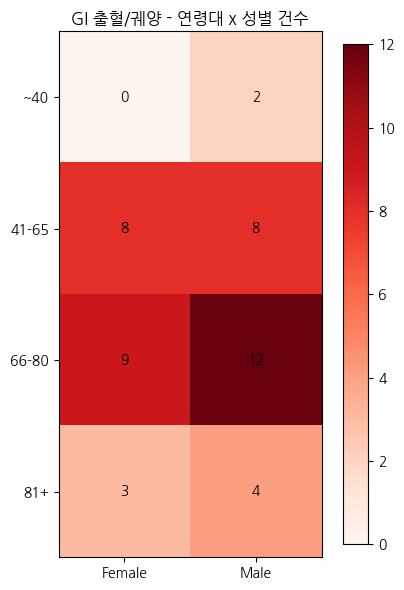

In [22]:
age_bins = pd.cut(gi["age_num"], bins=[0,40,65,80,120], labels=["~40","41-65","66-80","81+"])
ct = pd.crosstab(age_bins, gi["patient_sex"])

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(ct.values, cmap="Reds")
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
for i in range(len(ct.index)):
    for j in range(len(ct.columns)):
        ax.text(j, i, ct.values[i, j], ha="center", va="center")
ax.set_title("GI 출혈/궤양 - 연령대 x 성별 건수")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

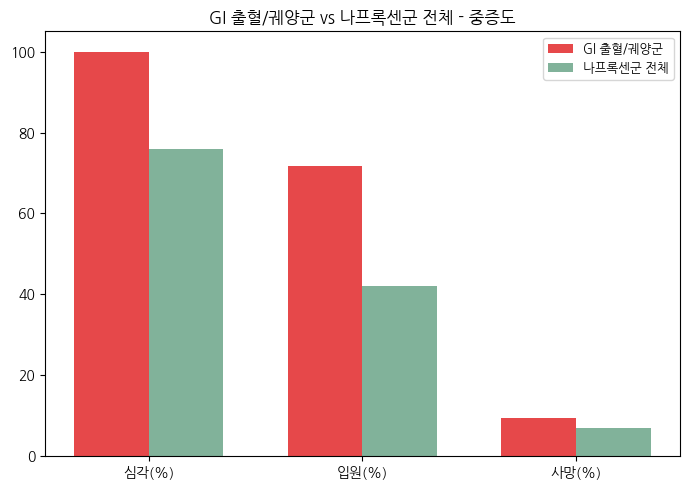

In [23]:
labels = ["심각(%)", "입원(%)", "사망(%)"]
gi_vals = [(gi["serious"]=="Yes").mean()*100, gi["is_hospitalized"].mean()*100, gi["is_fatal"].mean()*100]
all_vals = [(naproxen_group["serious"]=="Yes").mean()*100, naproxen_group["is_hospitalized"].mean()*100,
            naproxen_group["is_fatal"].mean()*100]

x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - w/2, gi_vals, w, label="GI 출혈/궤양군", color="#e6484a")
ax.bar(x + w/2, all_vals, w, label="나프록센군 전체", color="#81b29a")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("GI 출혈/궤양군 vs 나프록센군 전체 - 중증도")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [24]:

age_bins_all = pd.cut(naproxen_group["age_num"], bins=[0,40,65,80,120], labels=["~40","41-65","66-80","81+"])
naproxen_group["age_bin"] = age_bins_all

ct_age = pd.crosstab(naproxen_group["gi_event"], naproxen_group["age_bin"])
chi2_age, p_age, dof_age, _ = stats.chi2_contingency(ct_age)
print(f"[연령대 x GI여부] chi2={chi2_age:.2f}, p={p_age:.4g}")

ct_sex = pd.crosstab(naproxen_group["gi_event"],
                      naproxen_group["patient_sex"].where(naproxen_group["patient_sex"].isin(["Female","Male"])))
ct_sex = ct_sex.dropna(axis=1, how="all")
chi2_sex, p_sex, dof_sex, _ = stats.chi2_contingency(ct_sex)
print(f"[성별 x GI여부] chi2={chi2_sex:.2f}, p={p_sex:.4g}")

u_age, p_age_mw = stats.mannwhitneyu(gi["age_num"].dropna(),
                                      naproxen_group.loc[~naproxen_group["gi_event"], "age_num"].dropna())
print(f"[연령 GI vs 비GI] Mann-Whitney p={p_age_mw:.4g}, GI 중앙값 {gi['age_num'].median():.0f}세")

non_gi = naproxen_group[~naproxen_group["gi_event"]]
for label, col in [("심각","serious"), ("입원","is_hospitalized"), ("사망","is_fatal")]:
    gi_flag = (gi["serious"]=="Yes") if col=="serious" else gi[col]
    non_flag = (non_gi["serious"]=="Yes") if col=="serious" else non_gi[col]
    ct = [[gi_flag.sum(), len(gi)-gi_flag.sum()], [non_flag.sum(), len(non_gi)-non_flag.sum()]]
    chi2, p, _, _ = stats.chi2_contingency(ct)
    print(f"{label}: GI {gi_flag.mean()*100:.1f}% vs 비GI {non_flag.mean()*100:.1f}% | chi2={chi2:.1f}, p={p:.4g}")

[연령대 x GI여부] chi2=11.05, p=0.01148
[성별 x GI여부] chi2=10.74, p=0.001048
[연령 GI vs 비GI] Mann-Whitney p=0.0134, GI 중앙값 67세
심각: GI 100.0% vs 비GI 71.7% | chi2=18.2, p=1.947e-05
입원: GI 71.7% vs 비GI 37.1% | chi2=20.8, p=5.031e-06
사망: GI 9.4% vs 비GI 6.7% | chi2=0.2, p=0.6616


In [25]:
hyper_kws = ["Drug hypersensitivity", "Anaphylactic reaction", "Urticaria",
             "Angioedema", "Serum sickness-like reaction", "Cutaneous vasculitis"]

def has_hyper(text):
    if pd.isna(text): return False
    t = str(text).upper()
    return any(k.upper() in t for k in hyper_kws)

naproxen_group["hyper_event"] = naproxen_group["reactions"].apply(has_hyper)
hyper = naproxen_group[naproxen_group["hyper_event"]].copy()

print(f"과민반응/알레르기 관련 보고: {len(hyper)}건 / 나프록센군 전체 {len(naproxen_group)}건 ({len(hyper)/len(naproxen_group)*100:.1f}%)")
print("\n[제품군별]\n", hyper["sub_group"].value_counts())
print("\n[성별]\n", hyper["patient_sex"].value_counts())
print(f"\n[연령] 65세+: {(hyper['age_num']>=65).sum()}  <65세: {(hyper['age_num']<65).sum()}  결측: {hyper['age_num'].isna().sum()}")
print(f"\nserious 비율: {(hyper['serious']=='Yes').mean()*100:.1f}%")
print(f"사망 건수: {hyper['is_fatal'].sum()}")
print(f"생명위협 비율: {hyper['is_life_threat'].mean()*100:.1f}%")

과민반응/알레르기 관련 보고: 40건 / 나프록센군 전체 368건 (10.9%)

[제품군별]
 sub_group
처방용 나프록센          24
ALEVE(OTC 브랜드)    10
스토어브랜드             5
기타                 1
Name: count, dtype: int64

[성별]
 patient_sex
Female     32
Male        6
Unknown     2
Name: count, dtype: int64

[연령] 65세+: 10  <65세: 18  결측: 12

serious 비율: 55.0%
사망 건수: 0
생명위협 비율: 5.0%


In [26]:
hyper[hyper["is_life_threat"]][["report_id","quarter","patient_age_years","patient_sex","sub_group","reactions"]]

,report_id,quarter,patient_age_years,patient_sex,sub_group,reactions
3390,10671099,2015Q2,53.0,Female,ALEVE(OTC 브랜드),Drug hypersensitivity; Swollen tongue; Pharyng...
3440,10768121,2016Q1,56.0,Female,처방용 나프록센,Drug hypersensitivity; Pneumonia; Infusion rel...


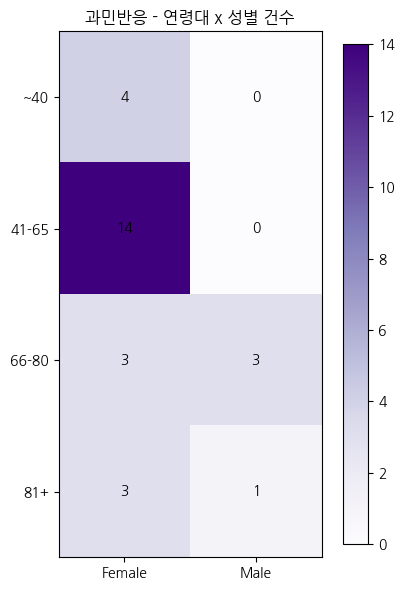

In [27]:
age_bins = pd.cut(hyper["age_num"], bins=[0,40,65,80,120], labels=["~40","41-65","66-80","81+"])
ct = pd.crosstab(age_bins, hyper["patient_sex"])

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(ct.values, cmap="Purples")
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
for i in range(len(ct.index)):
    for j in range(len(ct.columns)):
        ax.text(j, i, ct.values[i, j], ha="center", va="center")
ax.set_title("과민반응 - 연령대 x 성별 건수")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

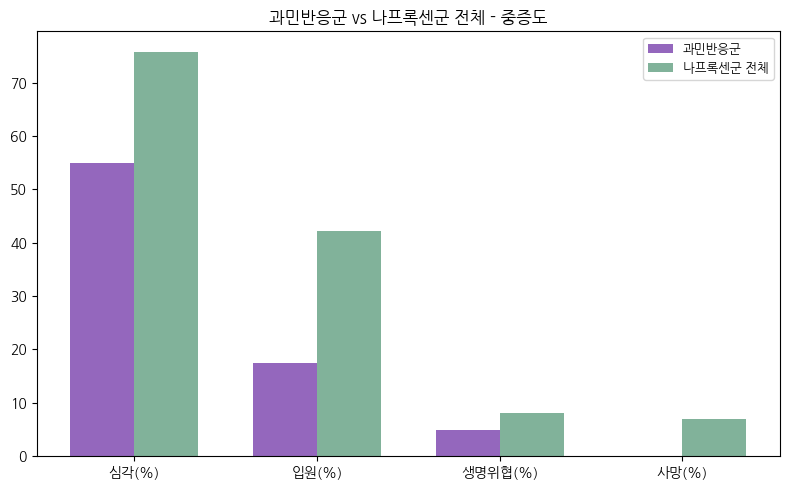

In [28]:
labels = ["심각(%)", "입원(%)", "생명위협(%)", "사망(%)"]
h_vals = [(hyper["serious"]=="Yes").mean()*100, hyper["is_hospitalized"].mean()*100,
          hyper["is_life_threat"].mean()*100, hyper["is_fatal"].mean()*100]
a_vals = [(naproxen_group["serious"]=="Yes").mean()*100, naproxen_group["is_hospitalized"].mean()*100,
          naproxen_group["is_life_threat"].mean()*100, naproxen_group["is_fatal"].mean()*100]

x = np.arange(4); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, h_vals, w, label="과민반응군", color="#9467bd")
ax.bar(x + w/2, a_vals, w, label="나프록센군 전체", color="#81b29a")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("과민반응군 vs 나프록센군 전체 - 중증도")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [29]:

age_bins_all = pd.cut(naproxen_group["age_num"], bins=[0,40,65,80,120], labels=["~40","41-65","66-80","81+"])
naproxen_group["age_bin"] = age_bins_all
non_hyper = naproxen_group[~naproxen_group["hyper_event"]]

ct_age = pd.crosstab(naproxen_group["hyper_event"], naproxen_group["age_bin"])
chi2_age, p_age, _, _ = stats.chi2_contingency(ct_age)
print(f"[연령대] chi2={chi2_age:.2f}, p={p_age:.4g}")

ct_sex = pd.crosstab(naproxen_group["hyper_event"],
                      naproxen_group["patient_sex"].where(naproxen_group["patient_sex"].isin(["Female","Male"])))
ct_sex = ct_sex.dropna(axis=1, how="all")
chi2_sex, p_sex, _, _ = stats.chi2_contingency(ct_sex)
print(f"[성별] chi2={chi2_sex:.2f}, p={p_sex:.4g}")

for label, col in [("심각","serious"), ("입원","is_hospitalized"), ("생명위협","is_life_threat"), ("사망","is_fatal")]:
    h_flag = (hyper["serious"]=="Yes") if col=="serious" else hyper[col]
    n_flag = (non_hyper["serious"]=="Yes") if col=="serious" else non_hyper[col]
    ct = [[h_flag.sum(), len(hyper)-h_flag.sum()], [n_flag.sum(), len(non_hyper)-n_flag.sum()]]
    chi2, p, _, _ = stats.chi2_contingency(ct)
    print(f"{label}: {h_flag.mean()*100:.1f}% vs {n_flag.mean()*100:.1f}% | chi2={chi2:.2f}, p={p:.4g}")

[연령대] chi2=0.91, p=0.8234
[성별] chi2=6.32, p=0.01195
심각: 55.0% vs 78.4% | chi2=9.37, p=0.002207
입원: 17.5% vs 45.1% | chi2=10.05, p=0.001521
생명위협: 5.0% vs 8.5% | chi2=0.22, p=0.6414
사망: 0.0% vs 7.9% | chi2=2.31, p=0.1284


In [30]:
def outcome_simple(x):
    if pd.isna(x):
        return "Unknown"
    tokens = [t.strip() for t in str(x).split(";")]
    if "Fatal" in tokens:
        return "Fatal"
    if "Not Recovered" in tokens:
        return "Not Recovered"
    if "Recovering" in tokens:
        return "Recovering"
    if "Recovered" in tokens:
        return "Recovered"
    return "Unknown"

naproxen_group["outcome_simple"] = naproxen_group["reaction_outcomes"].apply(outcome_simple)
rest["outcome_simple"] = rest["reaction_outcomes"].apply(outcome_simple)

order = ["Recovered","Recovering","Not Recovered","Fatal"]

n_known = naproxen_group[naproxen_group["outcome_simple"] != "Unknown"]
print(f"Unknown 제외: {len(n_known)}/{len(naproxen_group)}건")
print(n_known["outcome_simple"].value_counts().reindex(order))
print("\n비율(%)\n", (n_known["outcome_simple"].value_counts(normalize=True).reindex(order)*100).round(1))

Unknown 제외: 233/368건
outcome_simple
Recovered        87
Recovering       44
Not Recovered    99
Fatal             3
Name: count, dtype: int64

비율(%)
 outcome_simple
Recovered        37.3
Recovering       18.9
Not Recovered    42.5
Fatal             1.3
Name: proportion, dtype: float64


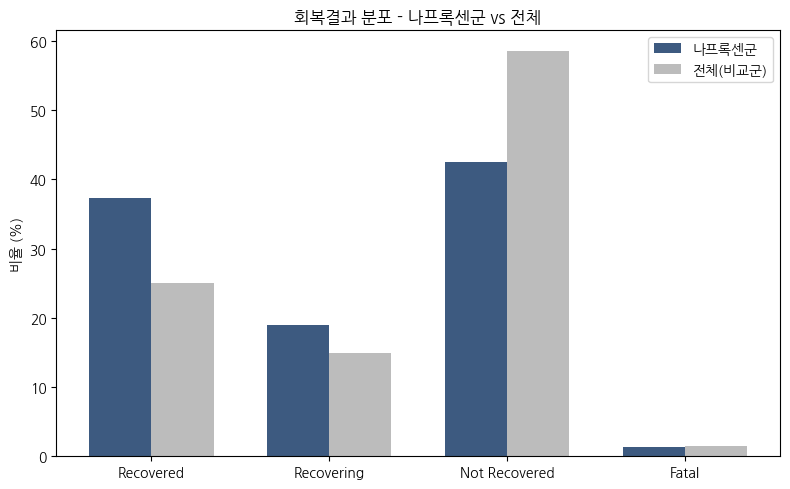

chi2=97.65, p=4.97e-21


In [31]:
r_known = rest[rest["outcome_simple"] != "Unknown"]

n_pct = n_known["outcome_simple"].value_counts(normalize=True).reindex(order).fillna(0)*100
r_pct = r_known["outcome_simple"].value_counts(normalize=True).reindex(order).fillna(0)*100

x = np.arange(len(order)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x-w/2, n_pct, w, label="나프록센군", color="#3d5a80")
ax.bar(x+w/2, r_pct, w, label="전체(비교군)", color="#bcbcbc")
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("비율 (%)")
ax.set_title("회복결과 분포 - 나프록센군 vs 전체")
ax.legend()
plt.tight_layout()
plt.show()

ct_outcome = pd.crosstab(
    pd.concat([n_known["outcome_simple"], r_known["outcome_simple"]]),
    pd.Series(["나프록센"]*len(n_known) + ["전체"]*len(r_known))
)
chi2, p, _, _ = stats.chi2_contingency(ct_outcome)
print(f"chi2={chi2:.2f}, p={p:.4g}")

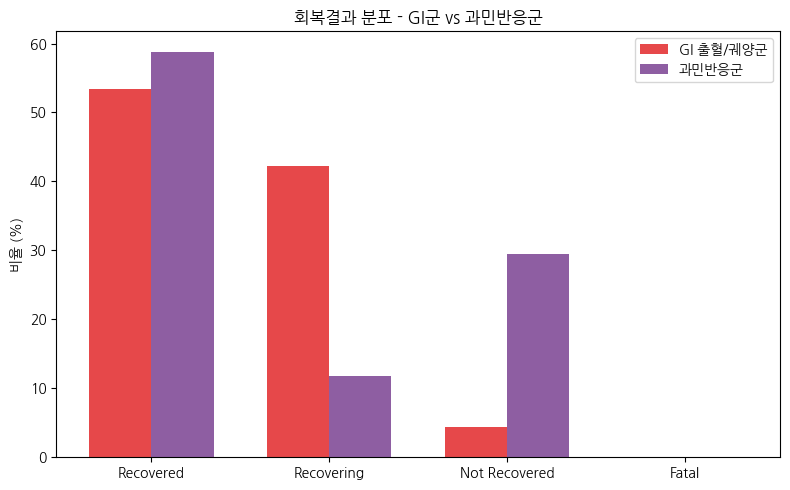

GI군 Not Recovered/Fatal 합계: 4.4% (n=45)
과민반응군 Not Recovered/Fatal 합계: 29.4% (n=17)


In [32]:
gi["outcome_simple"] = gi["reaction_outcomes"].apply(outcome_simple)
hyper["outcome_simple"] = hyper["reaction_outcomes"].apply(outcome_simple)

gi_known = gi[gi["outcome_simple"] != "Unknown"]
hyper_known = hyper[hyper["outcome_simple"] != "Unknown"]

gi_pct = gi_known["outcome_simple"].value_counts(normalize=True).reindex(order).fillna(0)*100
hyper_pct = hyper_known["outcome_simple"].value_counts(normalize=True).reindex(order).fillna(0)*100

x = np.arange(len(order)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x-w/2, gi_pct, w, label="GI 출혈/궤양군", color="#e6484a")
ax.bar(x+w/2, hyper_pct, w, label="과민반응군", color="#8e5ea2")
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("비율 (%)")
ax.set_title("회복결과 분포 - GI군 vs 과민반응군")
ax.legend()
plt.tight_layout()
plt.show()

print(f"GI군 Not Recovered/Fatal 합계: {gi_known['outcome_simple'].isin(['Not Recovered','Fatal']).mean()*100:.1f}% (n={len(gi_known)})")
print(f"과민반응군 Not Recovered/Fatal 합계: {hyper_known['outcome_simple'].isin(['Not Recovered','Fatal']).mean()*100:.1f}% (n={len(hyper_known)})")

In [33]:
naproxen_group["poor_outcome"] = naproxen_group["outcome_simple"].isin(["Not Recovered","Fatal"])
rest["poor_outcome"] = rest["outcome_simple"].isin(["Not Recovered","Fatal"])

age_bins_all = [0,40,65,80,120]
age_labels_all = ["~40","41-65","66-80","81+"]
naproxen_group["age_bin"] = pd.cut(naproxen_group["age_num"], bins=age_bins_all, labels=age_labels_all)
rest["age_num"] = pd.to_numeric(rest["patient_age_years"], errors="coerce")  # naproxen_group과 동일하게 rest에도 age_num 생성 (누락되어 있었음)
rest["age_bin"] = pd.cut(rest["age_num"], bins=age_bins_all, labels=age_labels_all)

n_known2 = naproxen_group[naproxen_group["outcome_simple"] != "Unknown"]
r_known2 = rest[rest["outcome_simple"] != "Unknown"]

summary = pd.DataFrame({
    "나프록센_n": n_known2.groupby("age_bin").size(),
    "나프록센_불량회복%": (n_known2.groupby("age_bin")["poor_outcome"].mean()*100),
    "전체_n": r_known2.groupby("age_bin").size(),
    "전체_불량회복%": (r_known2.groupby("age_bin")["poor_outcome"].mean()*100),
})
print(summary.round(1))
print(f"\n전체 비교: 나프록센 {n_known2['poor_outcome'].mean()*100:.1f}% vs 전체 {r_known2['poor_outcome'].mean()*100:.1f}%")

for ab in age_labels_all:
    n_sub = n_known2[n_known2["age_bin"]==ab]
    r_sub = r_known2[r_known2["age_bin"]==ab]
    if len(n_sub) >= 5 and len(r_sub) >= 5:
        ct = [[n_sub["poor_outcome"].sum(), len(n_sub)-n_sub["poor_outcome"].sum()],
              [r_sub["poor_outcome"].sum(), len(r_sub)-r_sub["poor_outcome"].sum()]]
        chi2, p, _, _ = stats.chi2_contingency(ct)
        print(f"{ab}: chi2={chi2:.2f}, p={p:.4g}")

         나프록센_n  나프록센_불량회복%  전체_n  전체_불량회복%
age_bin                                    
~40          25        32.0  1554      35.3
41-65        97        53.6  4438      69.2
66-80        57        19.3  2562      49.5
81+          19        26.3   676      30.5

전체 비교: 나프록센 43.8% vs 전체 60.1%
~40: chi2=0.02, p=0.893
41-65: chi2=10.04, p=0.001528
66-80: chi2=19.15, p=1.205e-05
81+: chi2=0.02, p=0.892


/tmp/ipykernel_740/3790563484.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "나프록센_n": n_known2.groupby("age_bin").size(),
/tmp/ipykernel_740/3790563484.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "나프록센_불량회복%": (n_known2.groupby("age_bin")["poor_outcome"].mean()*100),
/tmp/ipykernel_740/3790563484.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  "전체_n": r_known2.groupby("age_bin").size(),
/tmp/ipykerne

In [34]:
gi_known2 = gi_known.copy()  # gi_known에는 poor_outcome이 없어 n_known2와 동일하게 새로 계산 (누락되어 있었음)
hyper_known2 = hyper_known.copy()
gi_known2["poor_outcome"] = gi_known2["outcome_simple"].isin(["Not Recovered","Fatal"])
hyper_known2["poor_outcome"] = hyper_known2["outcome_simple"].isin(["Not Recovered","Fatal"])

for name, sub in [("GI군", gi_known2), ("과민반응군", hyper_known2), ("나프록센군 전체", n_known2)]:
    corr_val, p_val = stats.pointbiserialr(sub["poor_outcome"].astype(int), sub["num_drugs"])
    print(f"[{name}] 병용약물수 vs 불량회복: r={corr_val:.3f}, p={p_val:.4g}, n={len(sub)}")

[GI군] 병용약물수 vs 불량회복: r=0.641, p=2.09e-06, n=45
[과민반응군] 병용약물수 vs 불량회복: r=0.590, p=0.01272, n=17
[나프록센군 전체] 병용약물수 vs 불량회복: r=0.315, p=9.005e-07, n=233


In [35]:

tables = []
for ab in age_labels_all:
    n_sub = n_known2[n_known2["age_bin"]==ab]
    r_sub = r_known2[r_known2["age_bin"]==ab]
    if len(n_sub) >= 5 and len(r_sub) >= 5:
        a = n_sub["poor_outcome"].sum(); b = len(n_sub)-a
        c = r_sub["poor_outcome"].sum(); d = len(r_sub)-c
        tables.append([[a, b],[c, d]])

st = StratifiedTable(tables)

a_all = n_known2["poor_outcome"].sum(); b_all = len(n_known2)-a_all
c_all = r_known2["poor_outcome"].sum(); d_all = len(r_known2)-c_all
crude_or = (a_all*d_all)/(b_all*c_all)

print(f"비층화(crude) OR: {crude_or:.3f}")
print(f"연령 보정(MH) OR: {st.oddsratio_pooled:.3f}")
res = st.test_null_odds()
print(f"MH 검정: statistic={res.statistic:.2f}, p={res.pvalue:.4g}")

비층화(crude) OR: 0.518
연령 보정(MH) OR: 0.471
MH 검정: statistic=25.18, p=5.218e-07


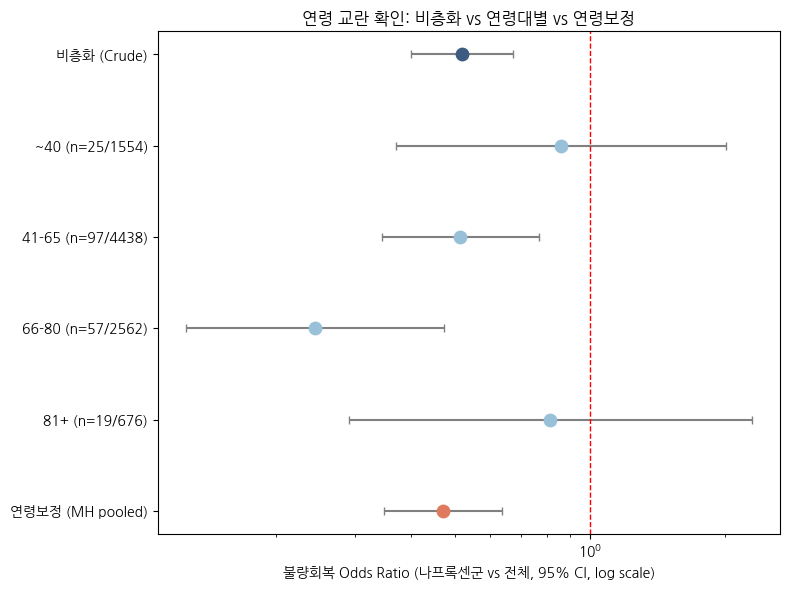

In [36]:

rows = []
tables = []
for ab in age_labels_all:
    n_sub = n_known2[n_known2["age_bin"]==ab]
    r_sub = r_known2[r_known2["age_bin"]==ab]
    if len(n_sub) >= 5 and len(r_sub) >= 5:
        a = n_sub["poor_outcome"].sum(); b = len(n_sub)-a
        c = r_sub["poor_outcome"].sum(); d = len(r_sub)-c
        a2, b2, c2, d2 = a, b, c, d
        if min(a, b, c, d) == 0:
            a2, b2, c2, d2 = a+0.5, b+0.5, c+0.5, d+0.5
        orv = (a2*d2)/(b2*c2)
        se = np.sqrt(1/a2+1/b2+1/c2+1/d2)
        lo = np.exp(np.log(orv)-1.96*se); hi = np.exp(np.log(orv)+1.96*se)
        rows.append((f"{ab} (n={len(n_sub)}/{len(r_sub)})", orv, lo, hi))
        tables.append([[a, b], [c, d]])

a_all = n_known2["poor_outcome"].sum(); b_all = len(n_known2)-a_all
c_all = r_known2["poor_outcome"].sum(); d_all = len(r_known2)-c_all
crude_or = (a_all*d_all)/(b_all*c_all)
se_crude = np.sqrt(1/a_all+1/b_all+1/c_all+1/d_all)
crude_lo = np.exp(np.log(crude_or)-1.96*se_crude)
crude_hi = np.exp(np.log(crude_or)+1.96*se_crude)

st = StratifiedTable(tables)
mh_or = st.oddsratio_pooled
mh_lo, mh_hi = st.oddsratio_pooled_confint()

plot_rows = [("비층화 (Crude)", crude_or, crude_lo, crude_hi)] + rows + [("연령보정 (MH pooled)", mh_or, mh_lo, mh_hi)]
labels = [r[0] for r in plot_rows]
ors = [r[1] for r in plot_rows]; los = [r[2] for r in plot_rows]; his = [r[3] for r in plot_rows]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(plot_rows))[::-1]
colors = ["#3d5a80"] + ["#98c1d9"]*len(rows) + ["#e07a5f"]

ax.errorbar(ors, y, xerr=[np.array(ors)-np.array(los), np.array(his)-np.array(ors)],
            fmt="o", color="black", ecolor="gray", capsize=3, zorder=1)
for i in range(len(plot_rows)):
    ax.scatter(ors[i], y[i], color=colors[i], s=80, zorder=2)

ax.axvline(1, color="red", linestyle="--", linewidth=1)
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xscale("log")
ax.set_xlabel("불량회복 Odds Ratio (나프록센군 vs 전체, 95% CI, log scale)")
ax.set_title("연령 교란 확인: 비층화 vs 연령대별 vs 연령보정")
plt.tight_layout()
plt.show()

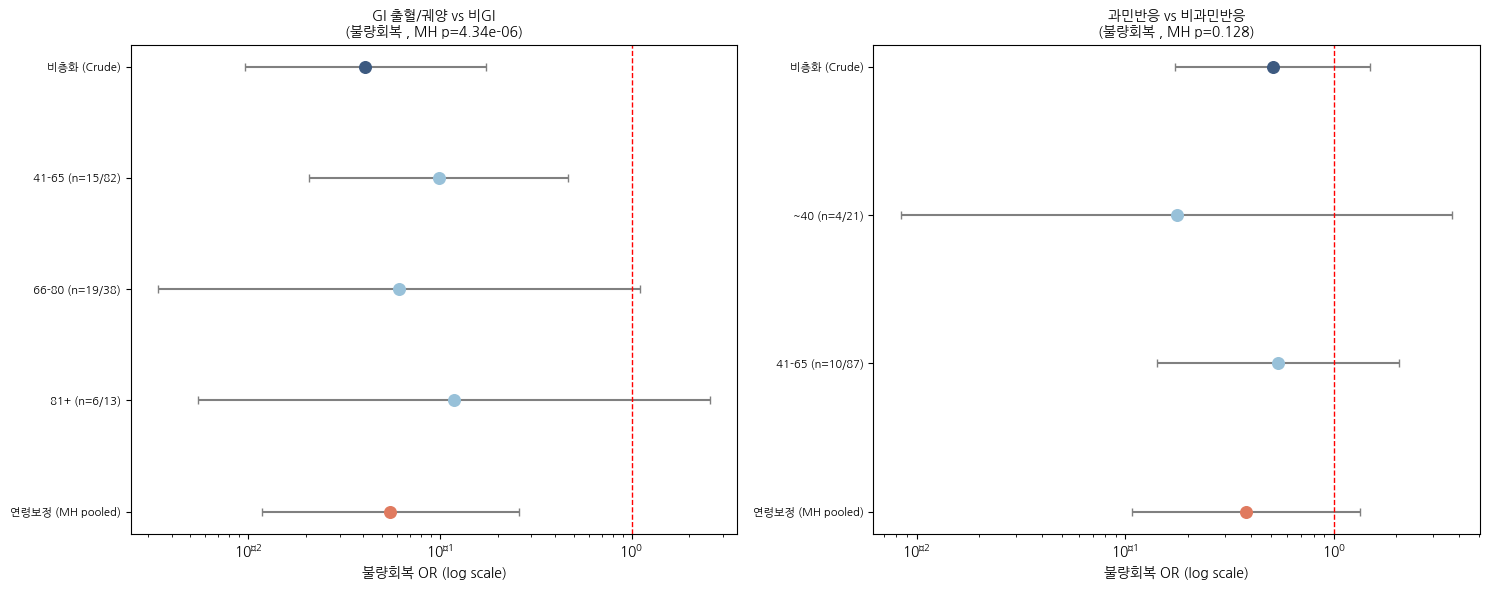

In [37]:
naproxen_group["poor_outcome"] = naproxen_group["outcome_simple"].isin(["Not Recovered","Fatal"])
nap_known = naproxen_group[naproxen_group["outcome_simple"] != "Unknown"].copy()
nap_known["age_bin"] = pd.cut(nap_known["age_num"], bins=age_bins_all, labels=age_labels_all)

def mh_summary(flag_col):
    tables = []; strata_rows = []
    for ab in age_labels_all:
        sub = nap_known[nap_known["age_bin"]==ab]
        exp = sub[sub[flag_col]]; nonexp = sub[~sub[flag_col]]
        if len(exp) >= 3 and len(nonexp) >= 3:
            a = exp["poor_outcome"].sum(); b = len(exp)-a
            c = nonexp["poor_outcome"].sum(); d = len(nonexp)-c
            a2,b2,c2,d2 = a,b,c,d
            if min(a,b,c,d)==0: a2,b2,c2,d2 = a+0.5,b+0.5,c+0.5,d+0.5
            orv = (a2*d2)/(b2*c2)
            se = np.sqrt(1/a2+1/b2+1/c2+1/d2)
            lo = np.exp(np.log(orv)-1.96*se); hi = np.exp(np.log(orv)+1.96*se)
            strata_rows.append((f"  {ab} (n={len(exp)}/{len(nonexp)})", orv, lo, hi))
            tables.append([[a,b],[c,d]])

    exp_all = nap_known[nap_known[flag_col]]; non_all = nap_known[~nap_known[flag_col]]
    a_all = exp_all["poor_outcome"].sum(); b_all = len(exp_all)-a_all
    c_all = non_all["poor_outcome"].sum(); d_all = len(non_all)-c_all
    a2,b2,c2,d2 = a_all,b_all,c_all,d_all
    if min(a2,b2,c2,d2)==0: a2,b2,c2,d2 = a2+0.5,b2+0.5,c2+0.5,d2+0.5
    crude = (a2*d2)/(b2*c2)
    se_c = np.sqrt(1/a2+1/b2+1/c2+1/d2)
    crude_lo = np.exp(np.log(crude)-1.96*se_c); crude_hi = np.exp(np.log(crude)+1.96*se_c)

    st = StratifiedTable(tables)
    mh_or = st.oddsratio_pooled
    mh_lo, mh_hi = st.oddsratio_pooled_confint()
    mh_p = st.test_null_odds().pvalue
    rows = [("비층화 (Crude)", crude, crude_lo, crude_hi)] + strata_rows + [("연령보정 (MH pooled)", mh_or, mh_lo, mh_hi)]
    return rows, mh_p

gi_rows, gi_p = mh_summary("gi_event")
hyper_rows, hyper_p = mh_summary("hyper_event")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, rows, title in [
    (axes[0], gi_rows, f"GI 출혈/궤양 vs 비GI\n(불량회복 , MH p={gi_p:.3g})"),
    (axes[1], hyper_rows, f"과민반응 vs 비과민반응\n(불량회복 , MH p={hyper_p:.3g})"),
]:
    labels = [r[0] for r in rows]
    ors = [r[1] for r in rows]; los = [r[2] for r in rows]; his = [r[3] for r in rows]
    y = np.arange(len(rows))[::-1]
    colors = ["#3d5a80"] + ["#98c1d9"]*(len(rows)-2) + ["#e07a5f"]
    ax.errorbar(ors, y, xerr=[np.array(ors)-np.array(los), np.array(his)-np.array(ors)],
                fmt="o", color="black", ecolor="gray", capsize=3, zorder=1)
    for i in range(len(rows)):
        ax.scatter(ors[i], y[i], color=colors[i], s=70, zorder=2)
    ax.axvline(1, color="red", linestyle="--", linewidth=1)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel("불량회복 OR (log scale)")
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.show()